In [1]:
from HARey.harey_main import HAReyMain

from matplotlib.font_manager import FontProperties
from datetime import datetime
import pytz

harey = HAReyMain(mw_file='HARey/mw_clean_10_deg.json')
harey.set_card_template(format='tarot', style='round')

# Set two custom fonts for the plots and the cards names
labels_font = FontProperties(fname='fonts/PatrickHand-Regular.ttf')
cardback_font = FontProperties(fname='fonts/TheWalkyr.ttf')

harey.set_fonts({'labels':labels_font, 'cardback':cardback_font})

Using the style file : /home/menegattig/Desktop/HARey_constellations_cards/HARey/default_style.yaml


Loading constellations diagrams....     Done!
Loading star coordinates....     Done!
Computing stars colors...     Done!
Loading custom markers....       Done!
Loading the object names....       Done!
Loading the milky way shape....       Done!


Using the tarot format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey_constellations_cards/HARey/cardbacks/tarot_round.png.
Using the tarot format, 2.75x4.75 in, using the template at /home/menegattig/Desktop/HARey_constellations_cards/HARey/cardbacks/tarot_round.png.


Using the style file : /home/menegattig/Desktop/HARey_constellations_cards/HARey/default_style.yaml




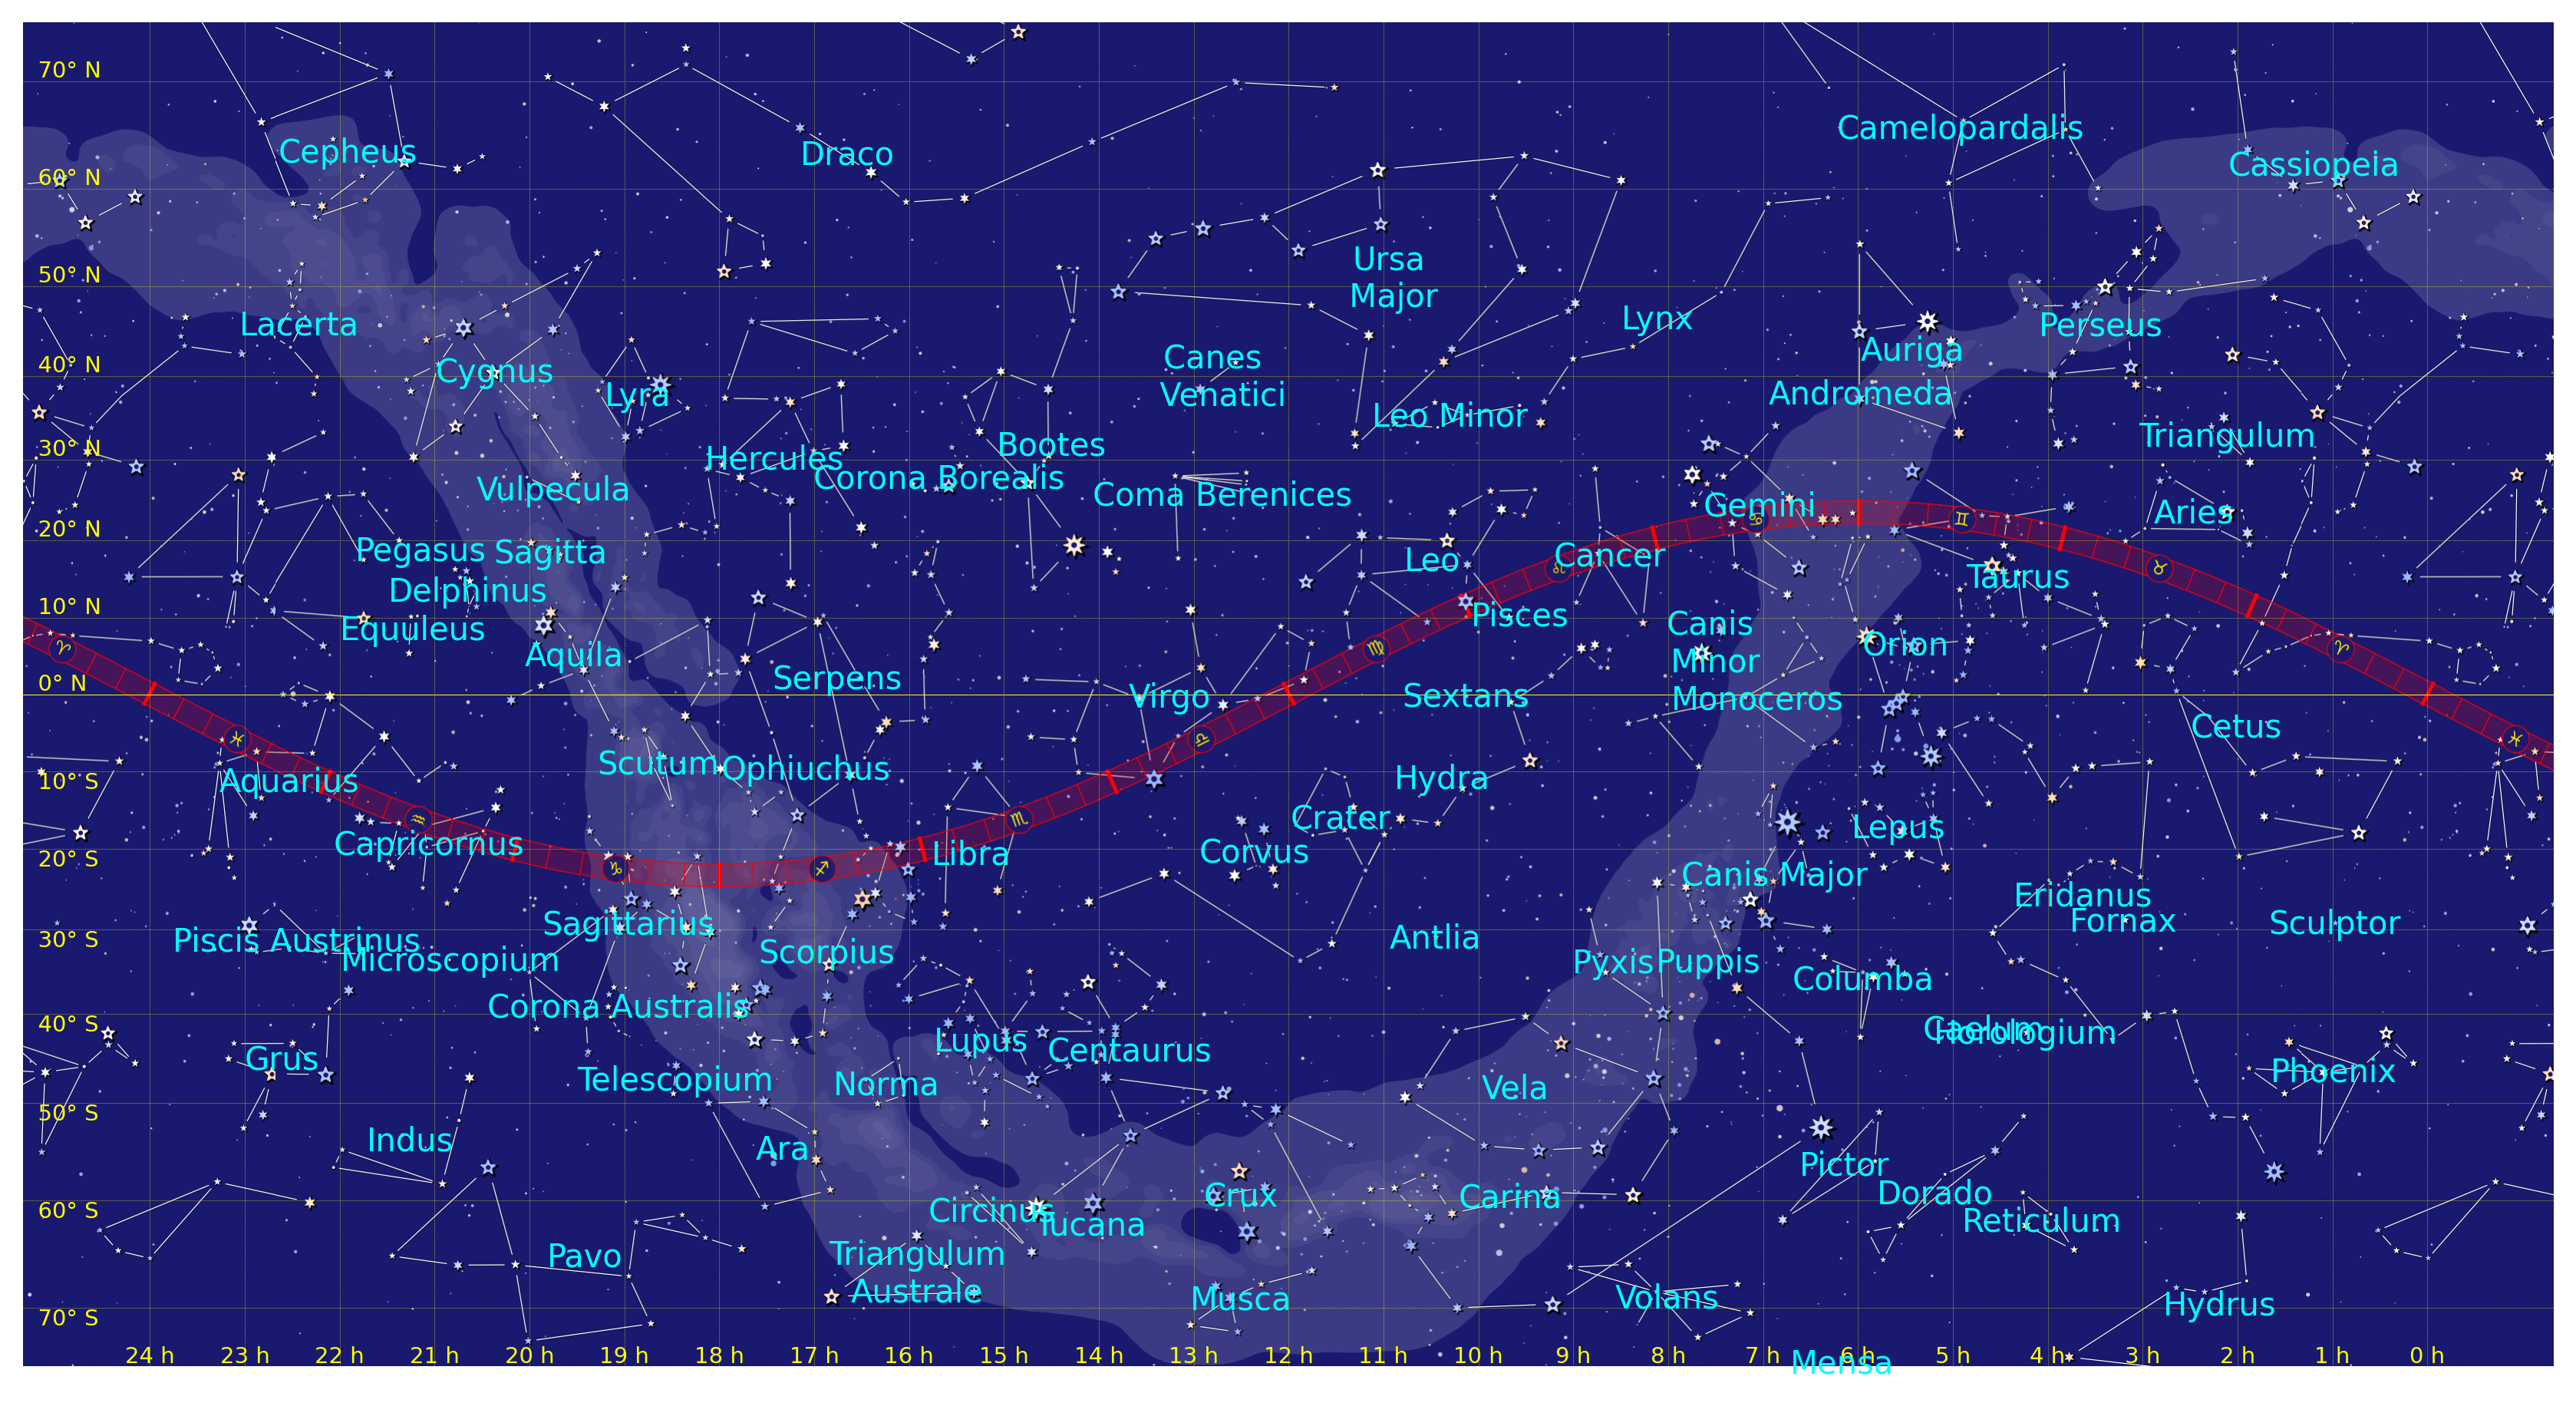

In [2]:
harey.load_style()
harey.equatorial_map('-con_parts', 'con_names', 'grid')

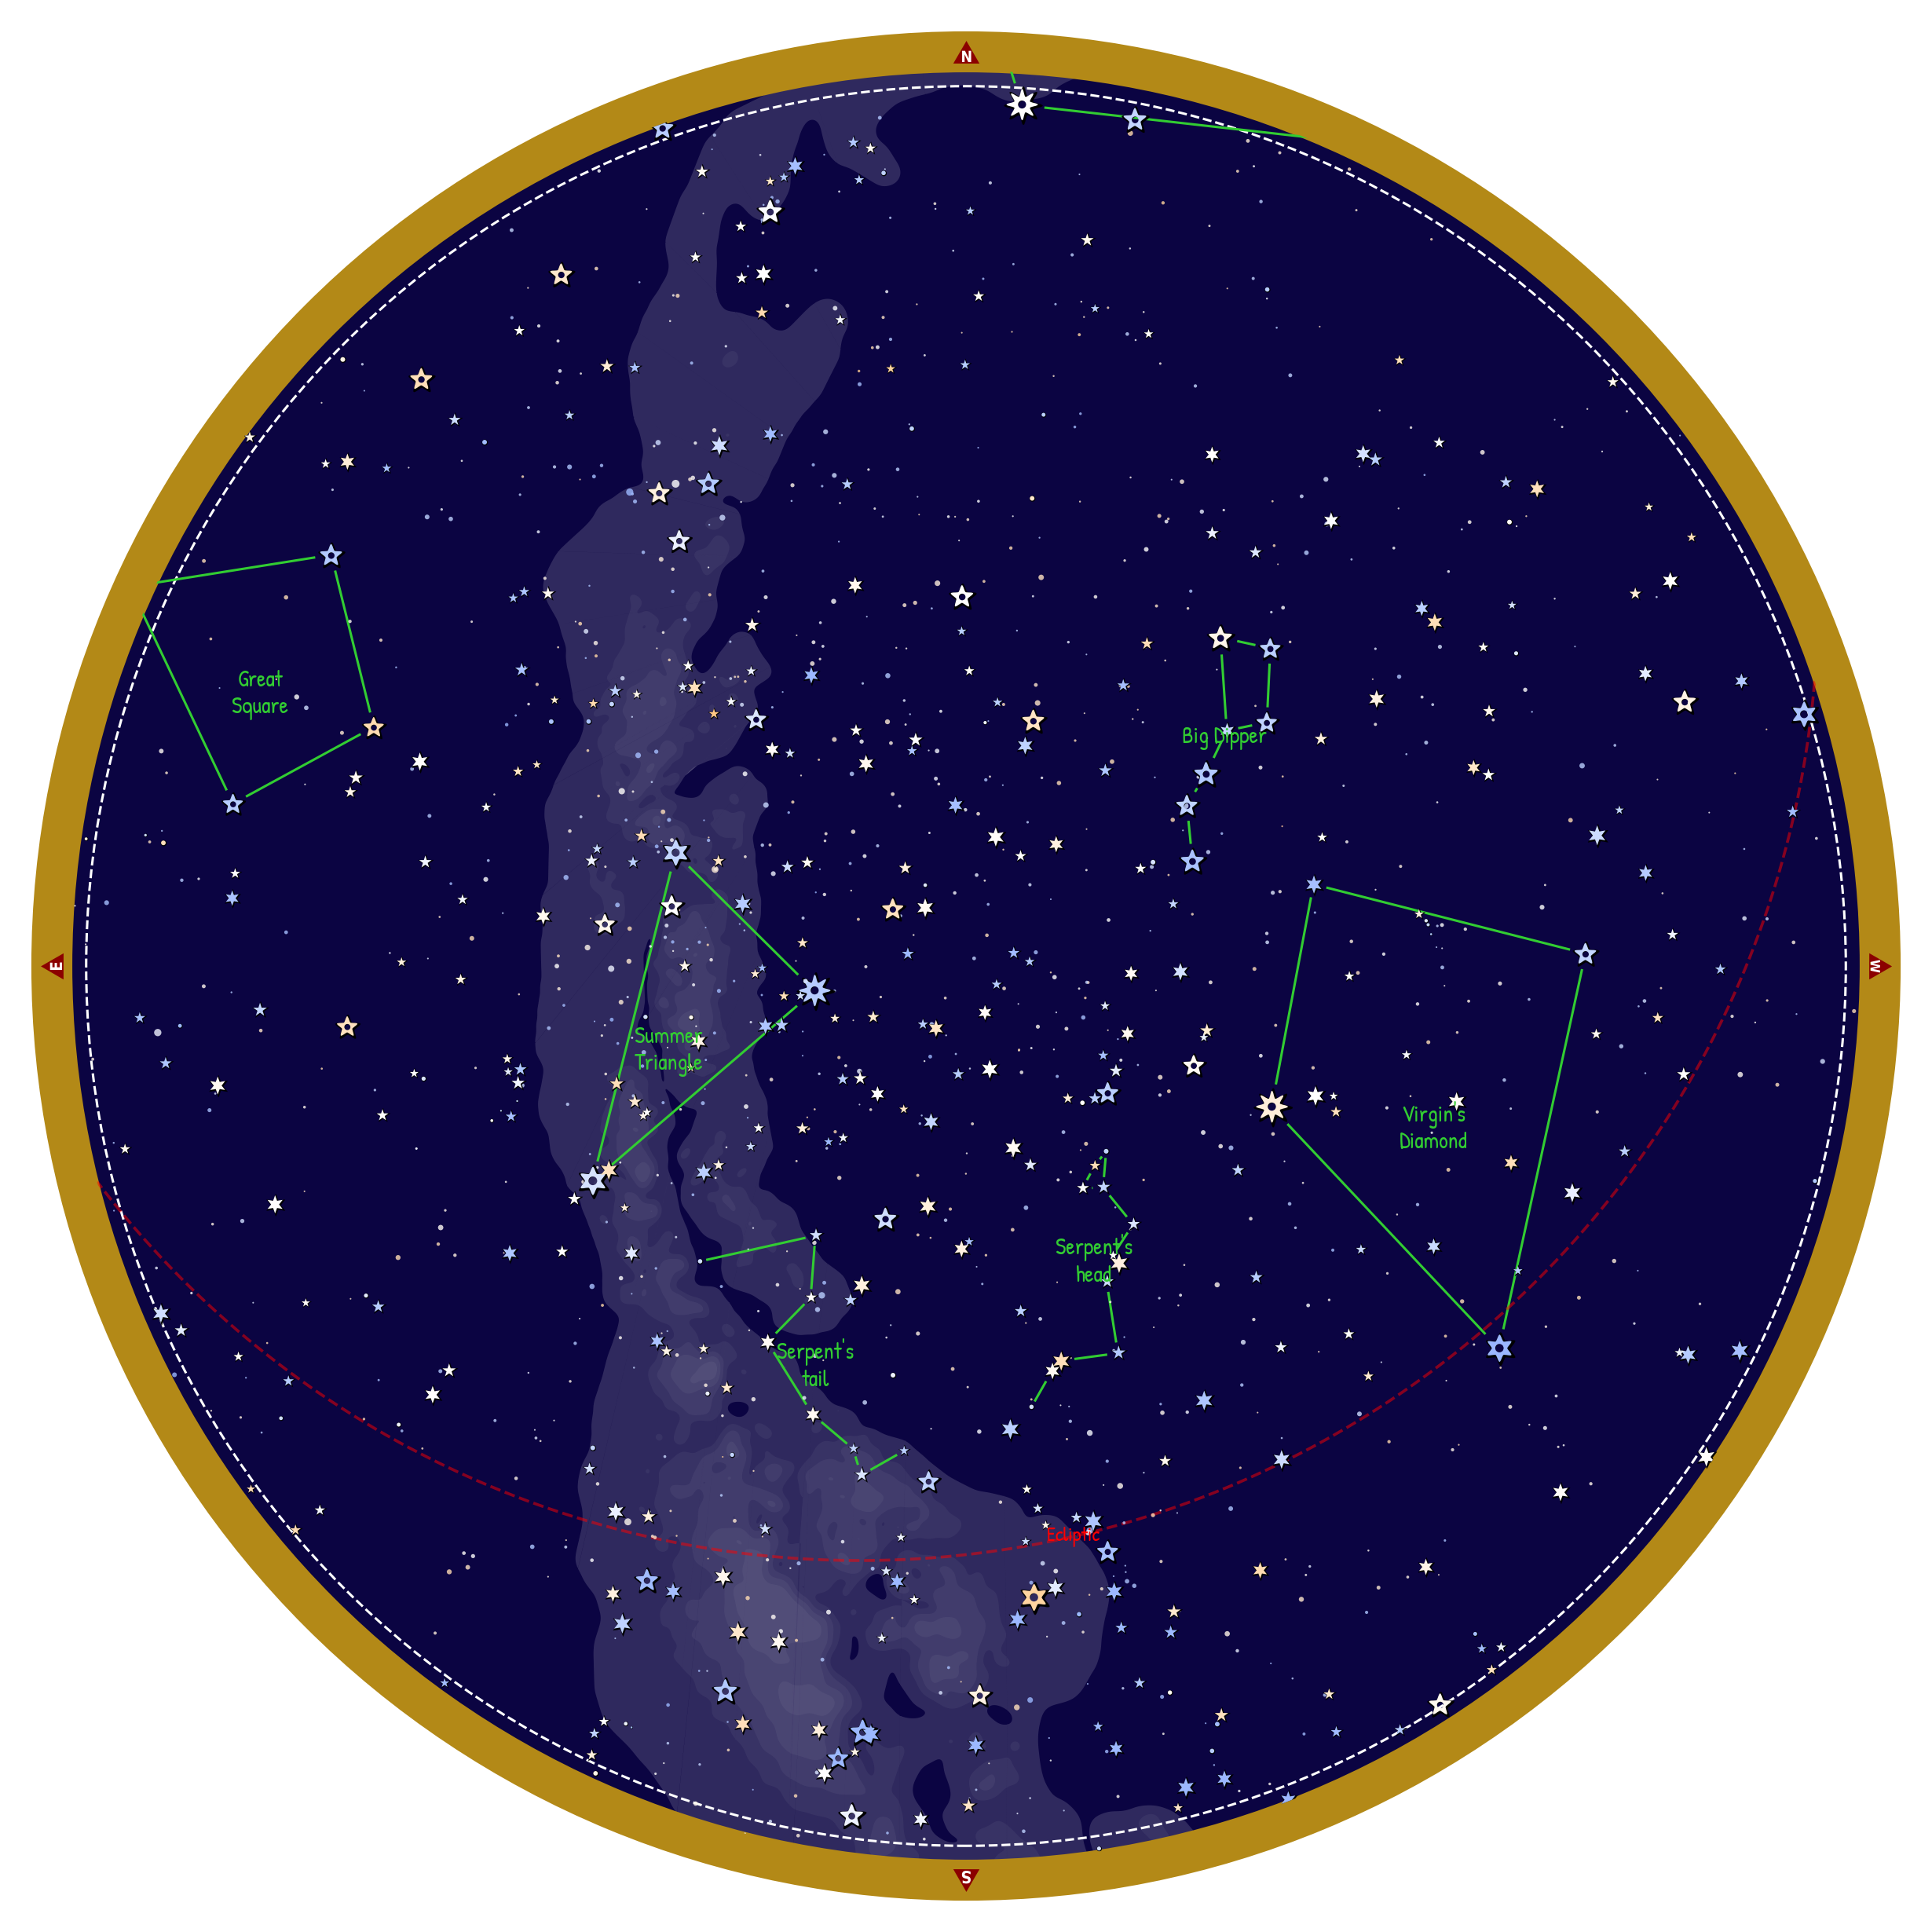

In [5]:
datetime_str = '1-8-2025 21:30'

date = datetime.strptime(datetime_str, '%d-%m-%Y %H:%M')
# Observer takes as input the latitude and longitude in decimal format (not sessagesimal)
observer = harey.Observer('45 N','11 E')
# Set the observation time and timezone
observer.at_time(date, pytz.timezone('Europe/Rome'))

flags = ('star_colors', '-star_names', 'asterisms', '-con_lines', '-zodiac', '-con_parts', 'ecliptic')
harey.plot_sky_view(observer, *flags)

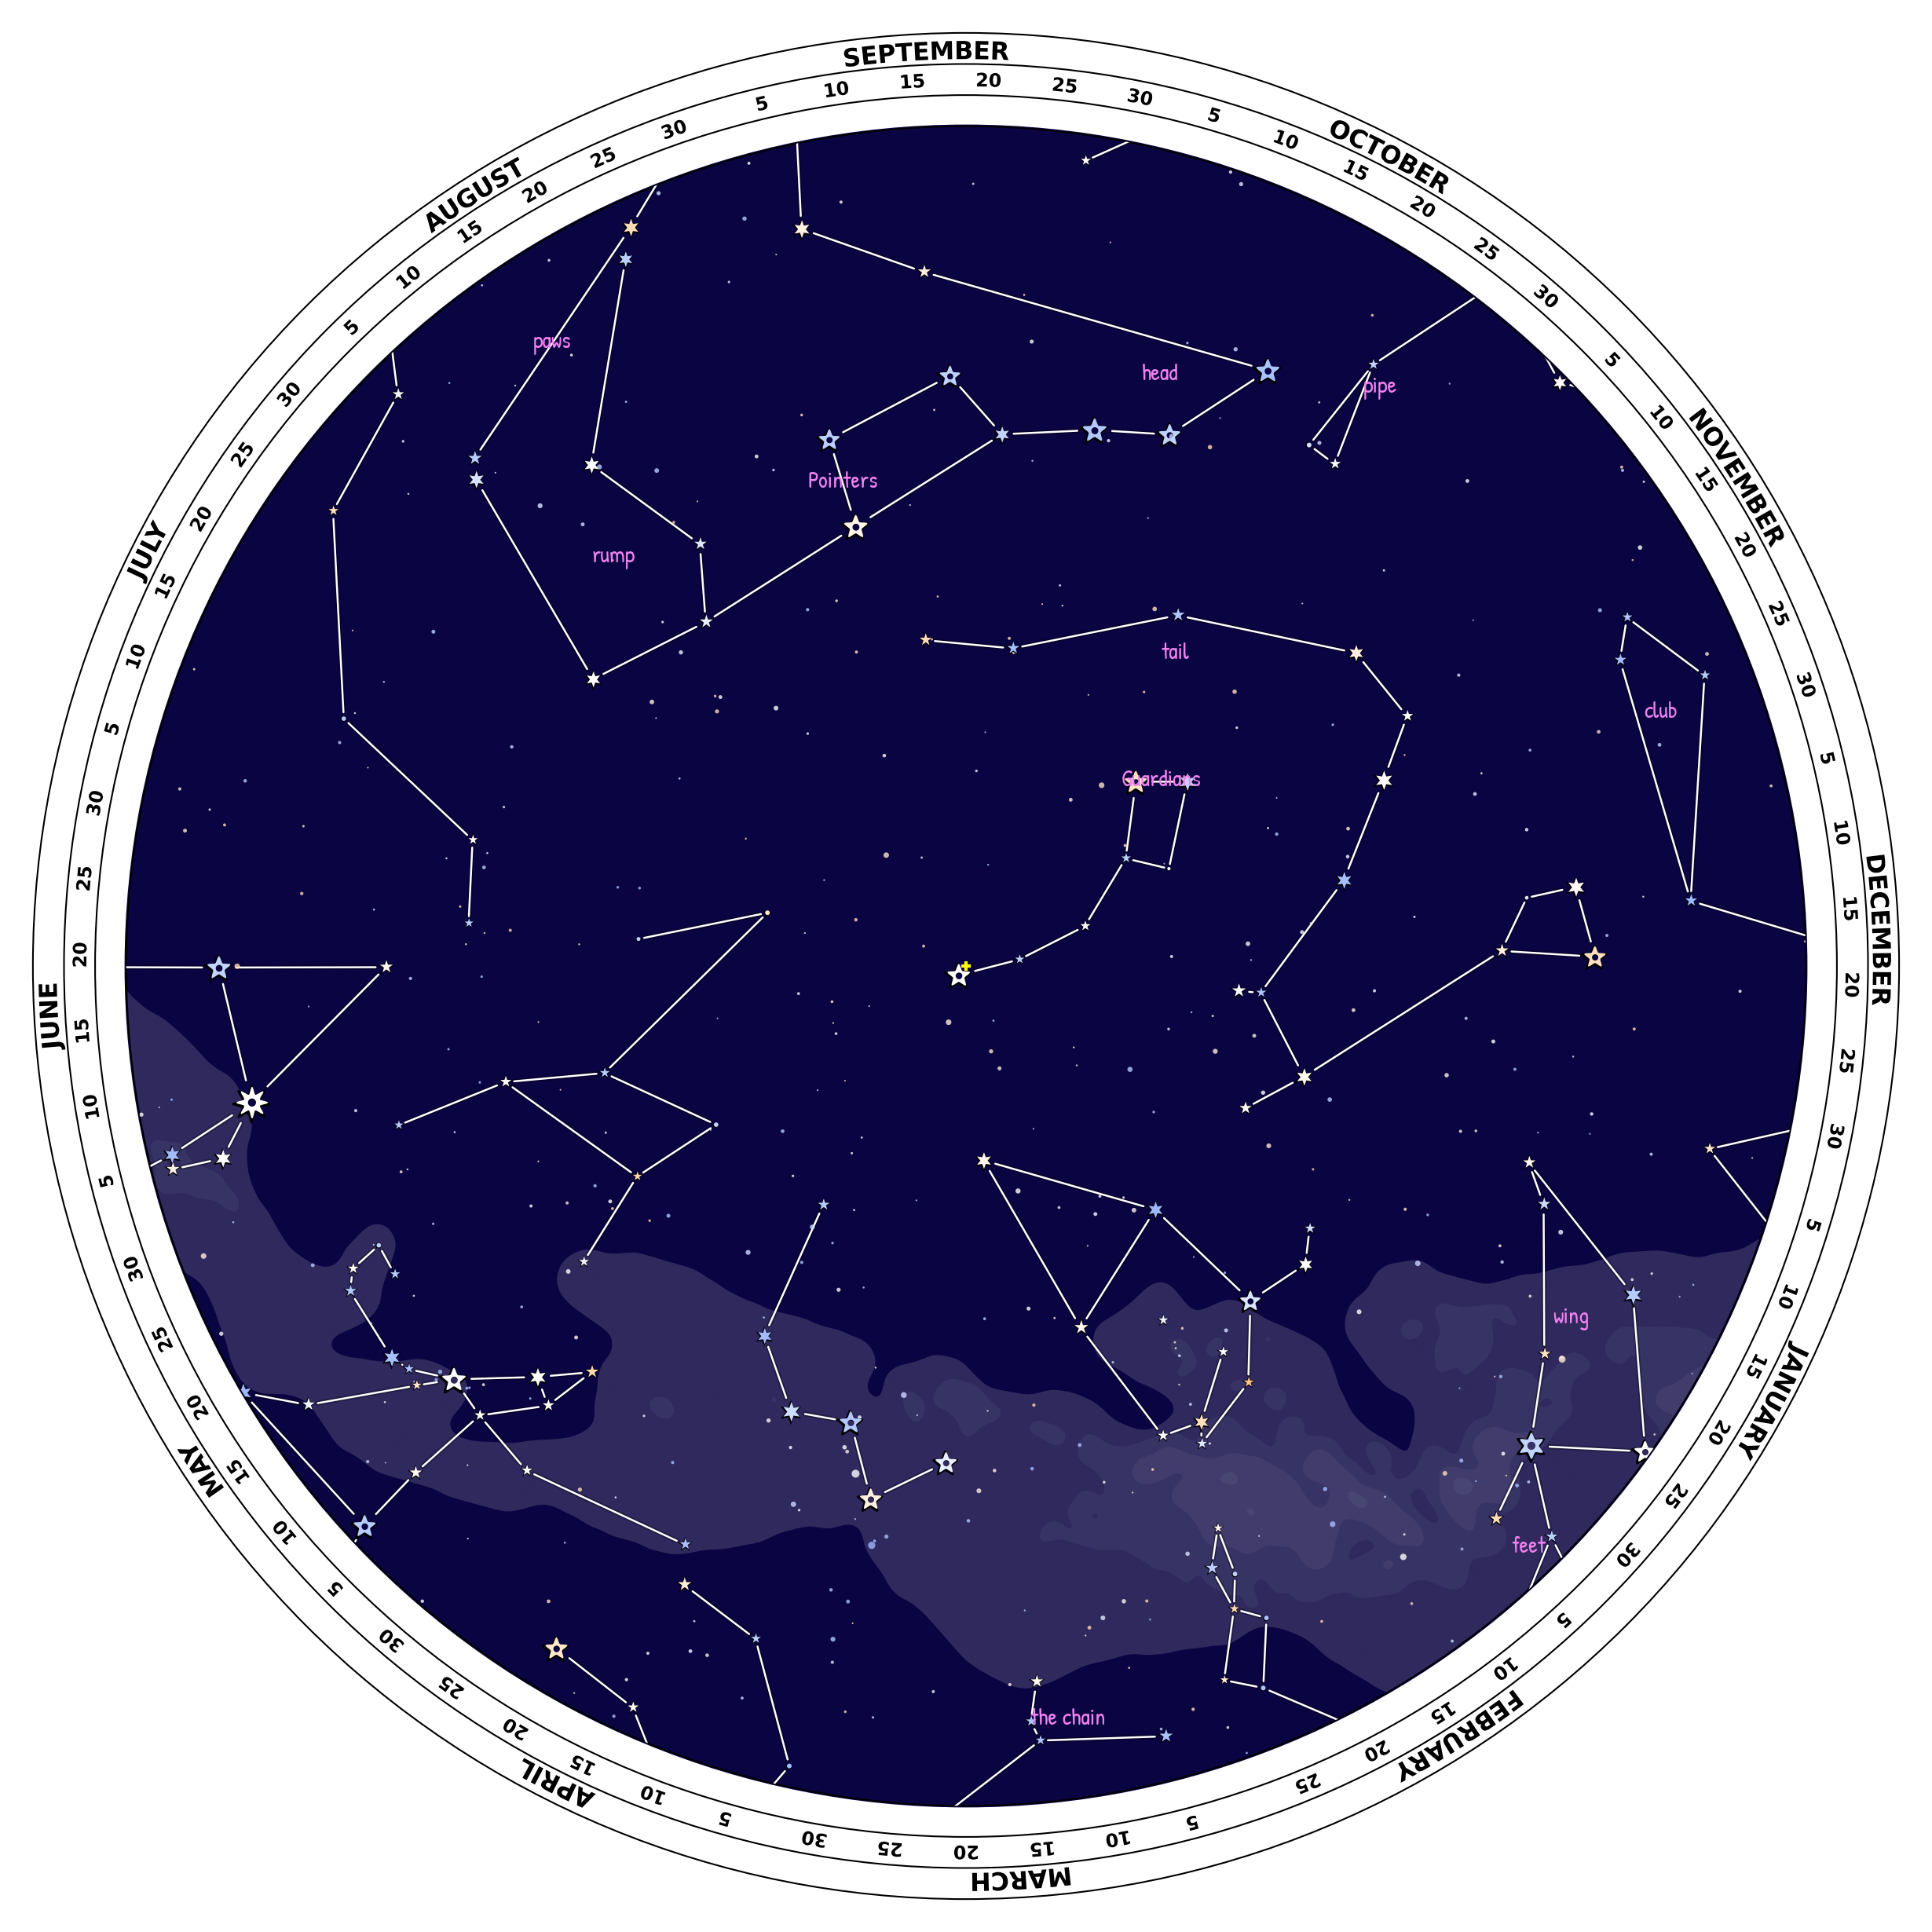

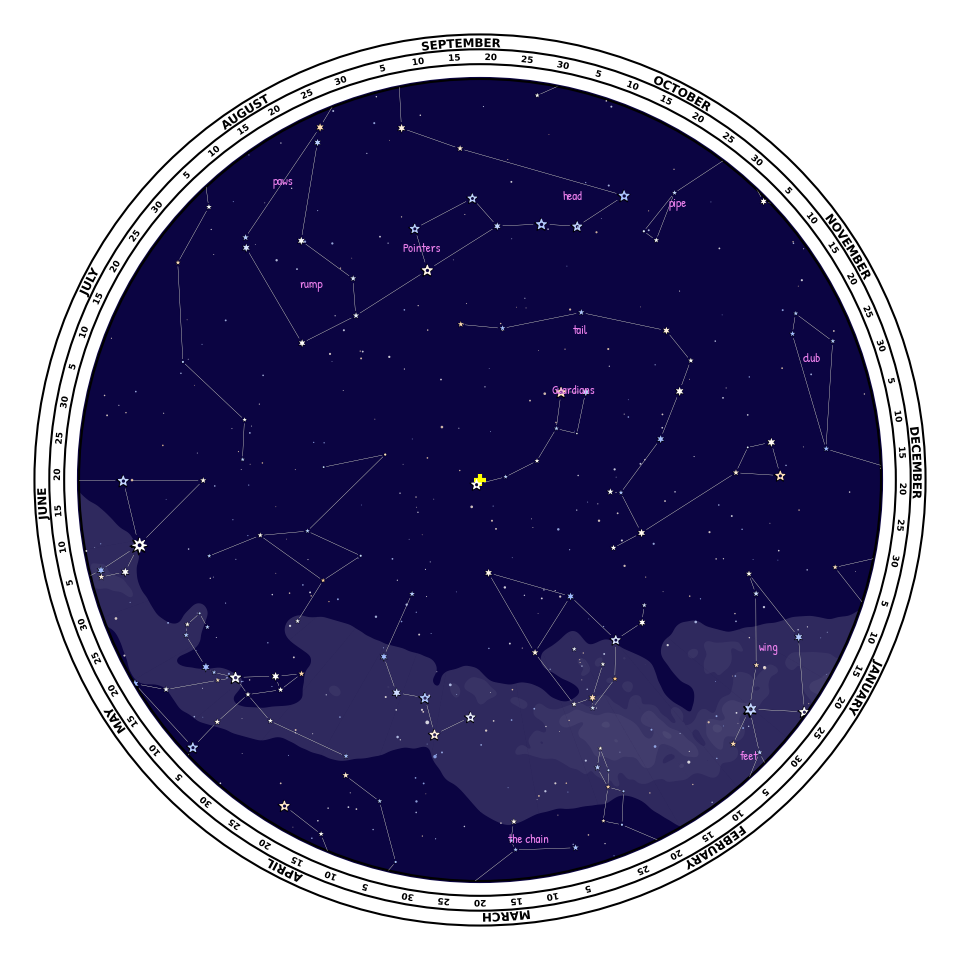

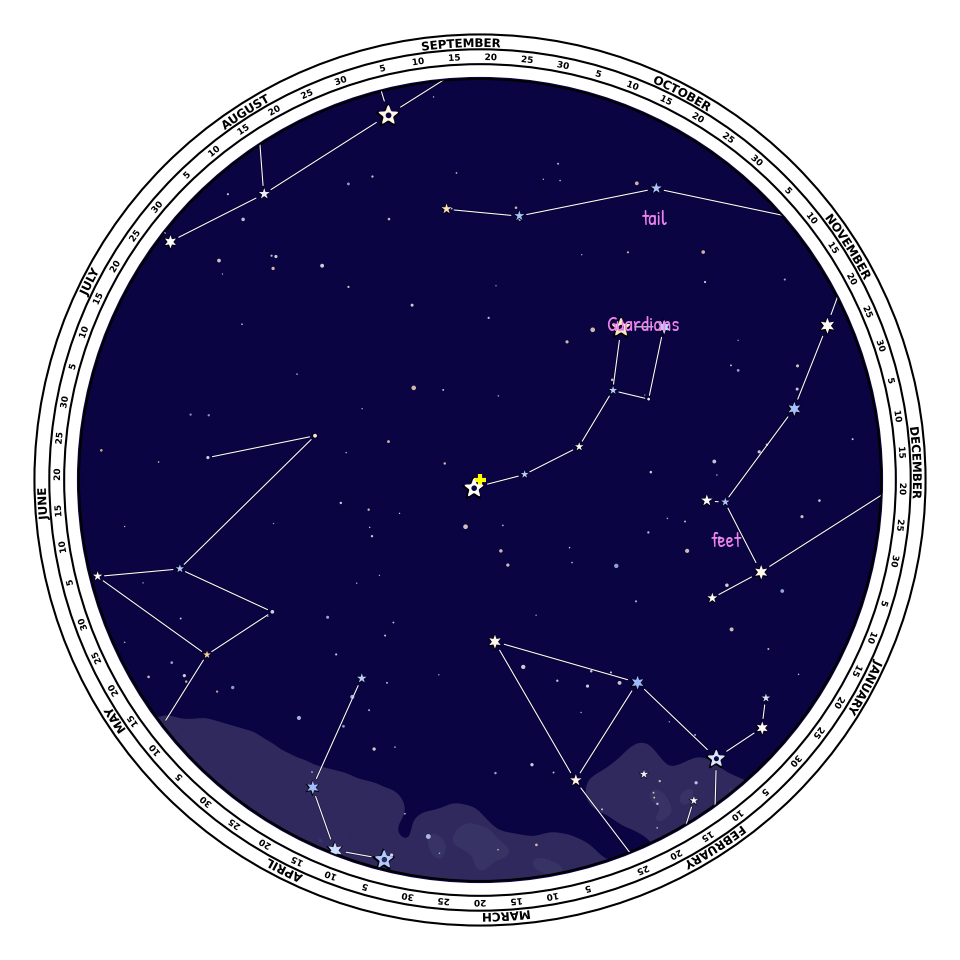

In [6]:
harey.polar_map(pole='N', ADD_CALENDAR=True, INVERT_CALENDAR=True, MARK_CENTER=True)
harey.polar_map(figsize=3, pole='N', ADD_CALENDAR=True, INVERT_CALENDAR=True, MARK_CENTER=True)
harey.polar_map(figsize=3, pole='N', ADD_CALENDAR=True, INVERT_CALENDAR=True, MARK_CENTER=True, FOV=60)

Using the style file : /home/menegattig/Desktop/HARey_constellations_cards/HARey/default_style.yaml




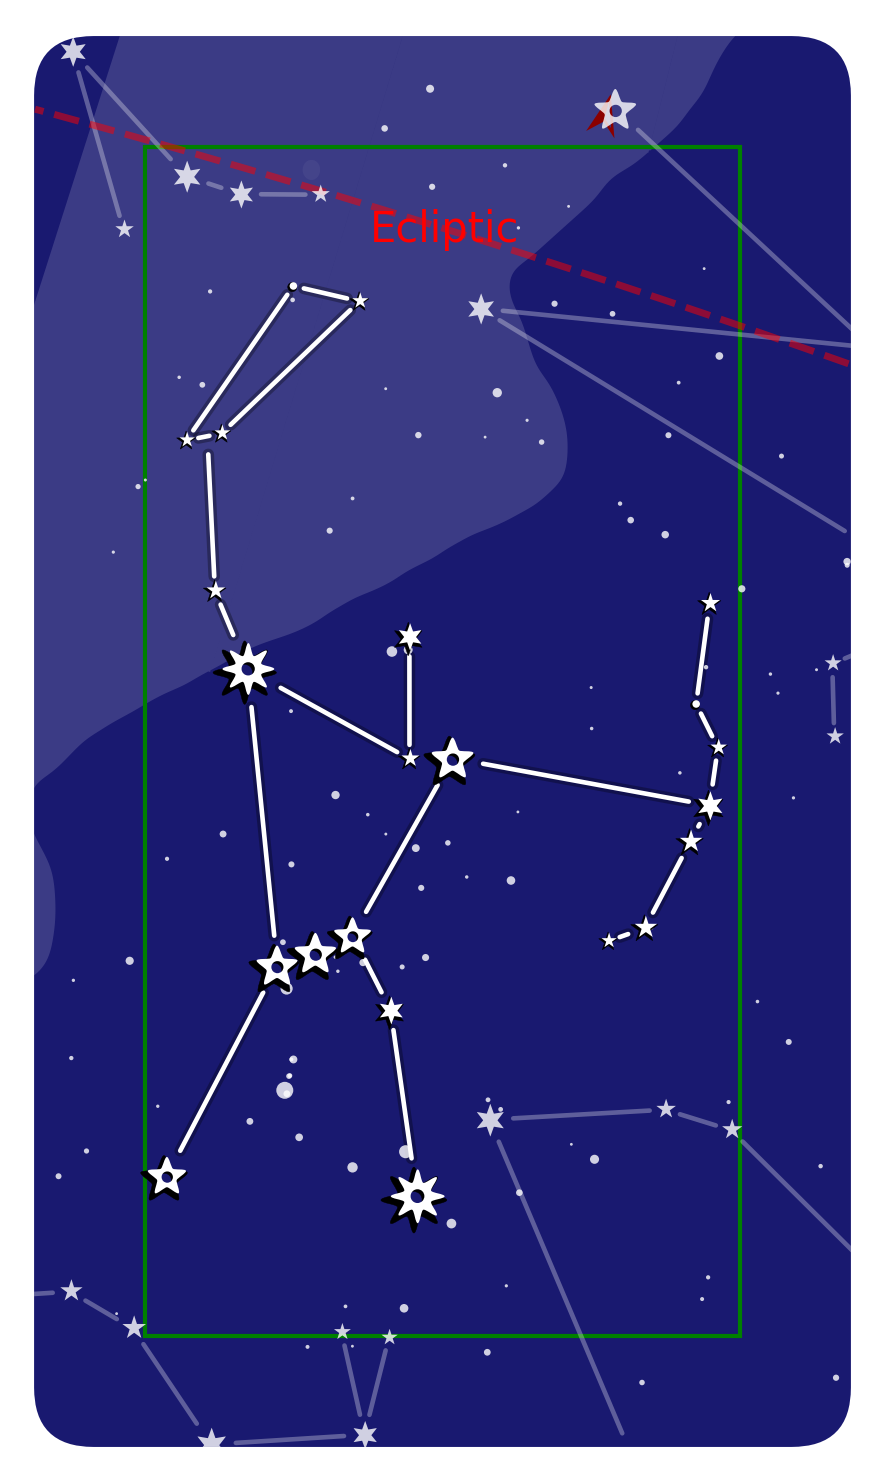

In [7]:
harey.load_style()
harey.set_limiting_magnitude(5.5, 0.01)
harey.set_flags('con_lines', '-star_names', '-star_colors', 'ecliptic', '-con_parts', 'milky_way', '-zodiac')
#harey.set_colors(sky="#0D006D", con_lines="#E6C13D", shadow="#1F1F1F", con_names="#F0D52B", stars="#F4C51D", milky_way="#6F3E2A")
harey.plot_card('show_guides', id='Ori', BEST_AR=True)

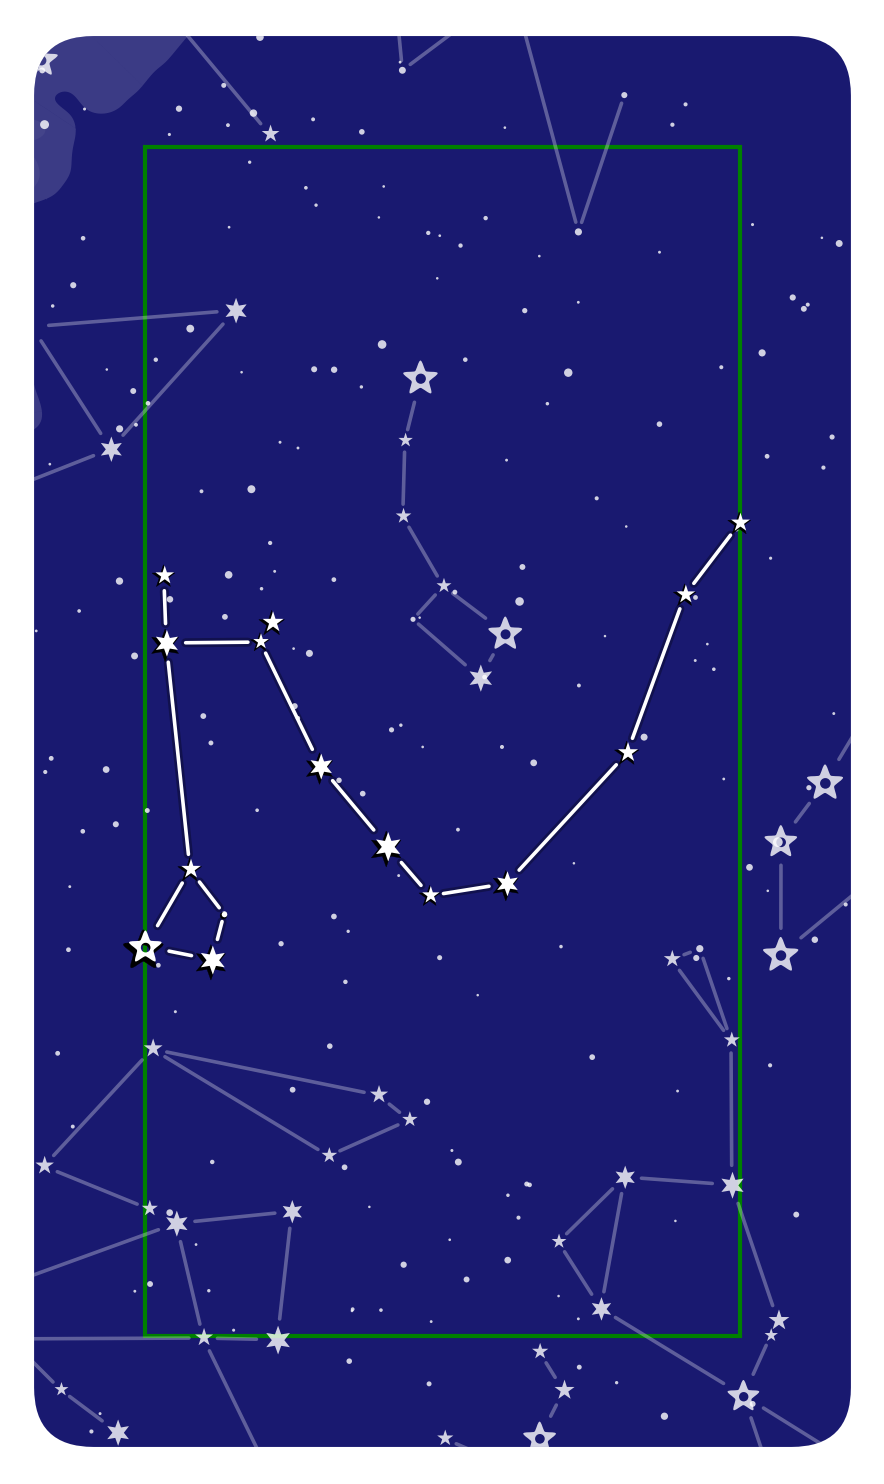

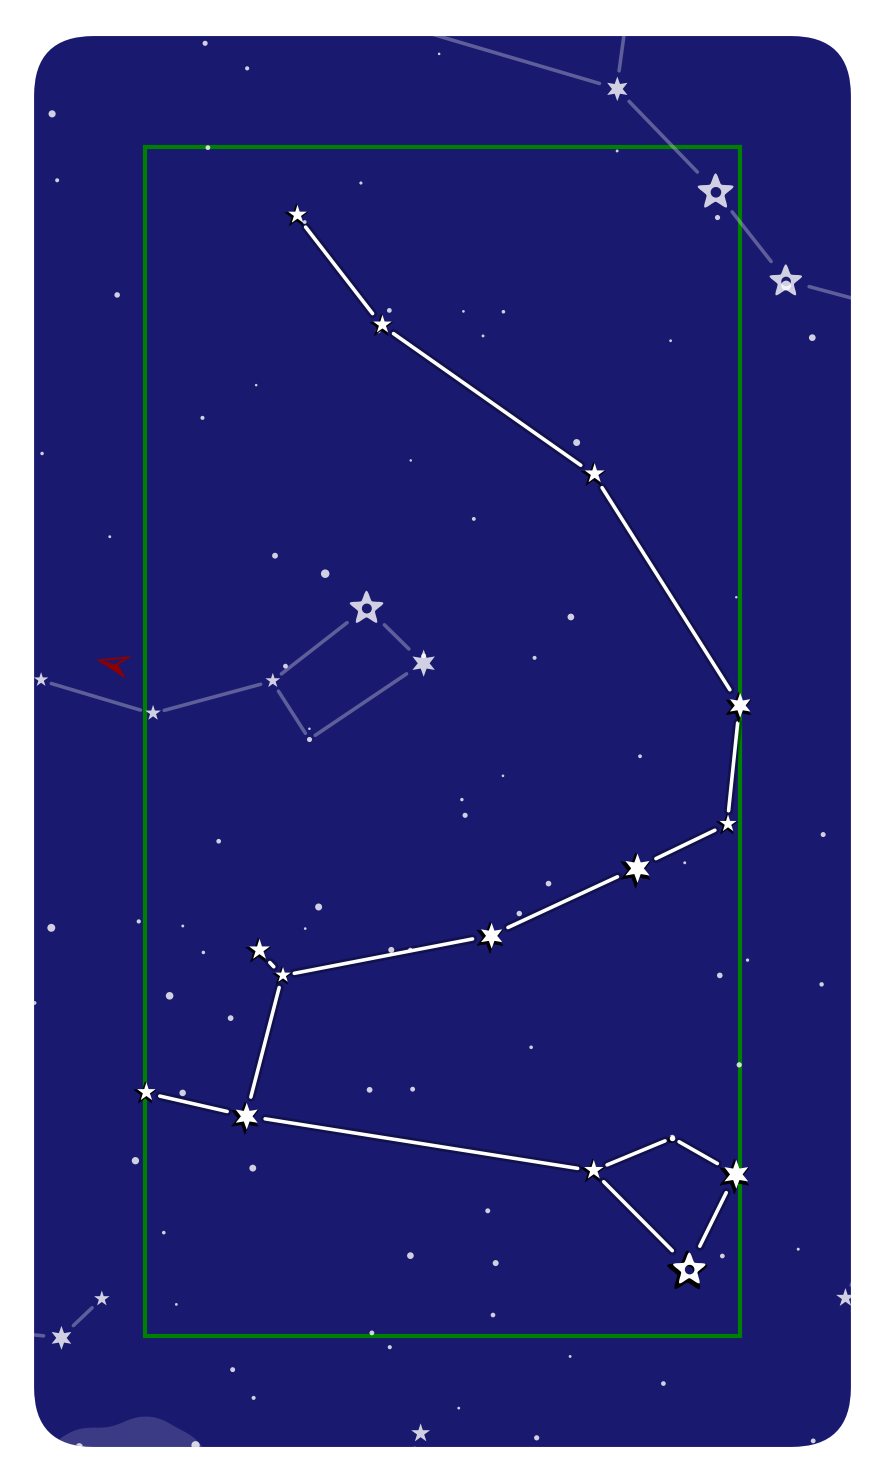

In [8]:
harey.plot_card( 'show_guides', id='Dra', save_name='Ori_true_star_colors.svg', BEST_AR=False)
harey.plot_card('show_guides', id='Dra', save_name='Ori_true_star_colors.svg', BEST_AR=True)

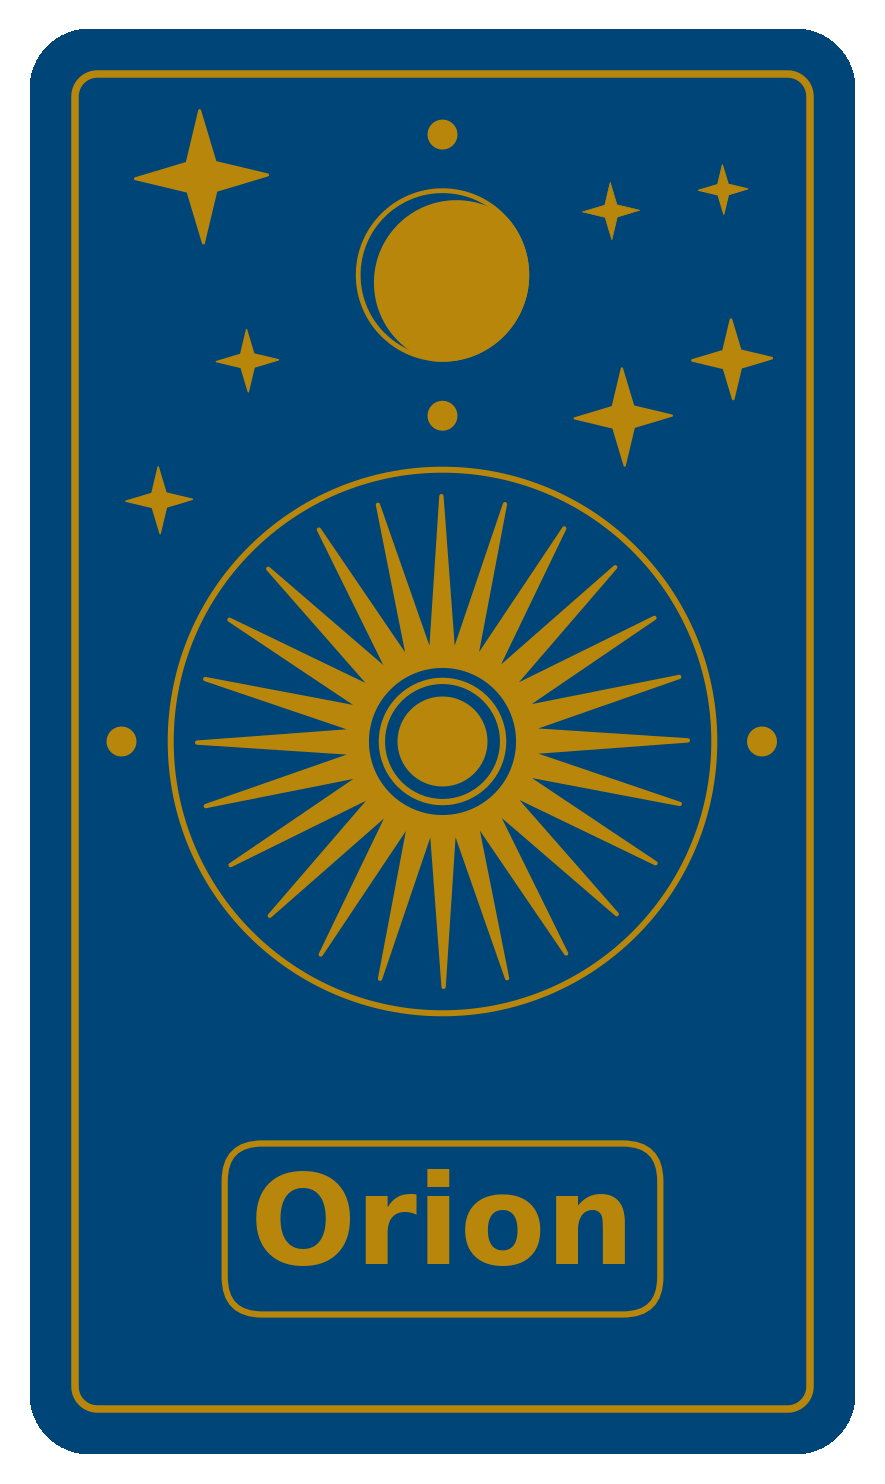

In [9]:
harey.plot_cardback(save_name='Ori_cardback.png')

In [10]:
flags = ('star_colors', 'con_lines', '-ecliptic', '-show', 'save')
for id in ['Ori', 'Gem', 'And', 'Aql']:
    harey.print_card_set(id = id, save_folder='output_dir', *flags, bleed=0.05)

Created card set for Ori
Created card set for Gem
Created card set for And
Created card set for Aql


In [ ]:
harey.set_card_template(format='poker')
harey.set_colors(con_lines='goldenrod')
harey.style['min_FOV'] = 5
flags = ('con_lines', 'ecliptic', 'star_colors', '-show', 'show_guides')

for id in harey.con_ids:
    print('Plotting ', id)
    harey.plot_card(id=id, *flags, save_name=f'all_images/{id}.png', BEST_AR=True)


Using the poker format, 2.50x3.50 in, using the template at /home/menegattig/Desktop/HARey_constellations_cards/HARey/cardbacks/poker_round.png.
Plotting  UMi
Plotting  Dra
Plotting  Cas
Plotting  Cep
Plotting  Cam
Plotting  UMa
Plotting  Leo
Plotting  CVn
Plotting  LMi
Plotting  Boo
Plotting  CrB
Plotting  Com
Plotting  Lyr
Plotting  Cyg
Plotting  Her
Plotting  Vul
Plotting  And
Plotting  Peg
Plotting  Tri
Plotting  Lac
Plotting  Per
Plotting  Tau
Plotting  Ari
Plotting  Gem
Plotting  Aur
Plotting  CMi
Plotting  Cnc
Plotting  Lyn
Plotting  Ori
Plotting  CMa
Plotting  Lep
Plotting  Mon
Plotting  Eri
Plotting  Hya
Plotting  Crt
Plotting  Ant
Plotting  Vir
Plotting  Lib
Plotting  Crv
Plotting  Oph
Plotting  Ser
Plotting  Sco
Plotting  Aql
Plotting  Sgr
Plotting  Sge
Plotting  Del
Plotting  CrA
Plotting  Sct
Plotting  Cap
Plotting  Aqr
Plotting  Equ
Plotting  PsA
Plotting  Gru
Plotting  Phe
Plotting  Psc
Plotting  Cet
Plotting  Scl
Plotting  Car
Plotting  Pup
Plotting  Vel
Plotting  Pyx
P

# Working interactive example

In [17]:
harey.load_style('config_current.yaml')
def update_plot(*args):

    sync_widgets_to_config()

    with out:

        out.clear_output(wait=True)

        harey.load_style(style_dict=config)
        #harey.plot_card(id="Sco", BEST_AR=True)
        harey.polar_map(pole='S', FOV=200)

Using the style file : config_current.yaml




In [18]:
import yaml
import ipywidgets as widgets

from ipywidgets import (VBox, HBox, Output, ColorPicker, Checkbox, Button, Accordion)

from matplotlib.colors import to_hex

with open("HARey/default_style.yaml", "r") as f:
    config = yaml.safe_load(f)


out = Output()
widget_map = {}


def set_nested(cfg, path, value):
    keys = path.split(".")
    d = cfg

    for k in keys[:-1]:
        d = d[k]

    d[keys[-1]] = value


def get_widget_value(widget):
    """
    Recover the python value from any widget.
    """

    if isinstance(widget, widgets.ColorPicker):
        return widget.value

    if isinstance(widget, widgets.Checkbox):
        return widget.value

    if isinstance(
        widget,
        (
            widgets.IntText,
            widgets.FloatText,
        )
    ):
        return widget.value

    if isinstance(widget, widgets.HBox):

        values = []

        for child in widget.children:

            if isinstance(child, widgets.IntText):
                values.append(child.value)

            elif isinstance(child, widgets.FloatText):
                values.append(child.value)

            else:
                values.append(child.value)

        return values

    return widget.value


# =====================================================
# SYNC WIDGETS -> CONFIG
# =====================================================

def sync_widgets_to_config():

    for path, widget in widget_map.items():

        set_nested(
            config,
            path,
            get_widget_value(widget)
        )


# =====================================================
# REPLOT CALLBACK
# =====================================================




# =====================================================
# LIST EDITOR
# =====================================================

def make_list_widget(values, description):

    children = []

    for v in values:

        if isinstance(v, int):

            w = widgets.IntText(
                value=v,
                layout=widgets.Layout(width="70px")
            )

        elif isinstance(v, float):

            w = widgets.FloatText(
                value=v,
                step=0.01,
                layout=widgets.Layout(width="90px")
            )

        else:

            w = widgets.Text(
                value=str(v),
                layout=widgets.Layout(width="90px")
            )

        w.observe(update_plot, names="value")

        children.append(w)

    label = widgets.Label(
        description,
        layout=widgets.Layout(width="120px")
    )

    return HBox([label] + children)


# =====================================================
# RECURSIVE UI BUILDER
# =====================================================

def build_section(data, prefix=""):

    controls = []

    for key, value in data.items():

        path = f"{prefix}.{key}" if prefix else key

        # ------------------------------------------------
        # Nested dictionaries
        # ------------------------------------------------

        if isinstance(value, dict):

            child = build_section(value, path)

            acc = Accordion(children=[child])
            acc.set_title(0, key)

            controls.append(acc)

            continue

        # ------------------------------------------------
        # COLORS
        # ------------------------------------------------

        if path.startswith("colors."):

            try:
                color_value = to_hex(value)

            except Exception:
                color_value = "#ffffff"

            w = ColorPicker(
                description=key,
                value=color_value,
                layout=widgets.Layout(width="300px")
            )

            w.observe(update_plot, names="value")

        # ------------------------------------------------
        # BOOLEANS
        # ------------------------------------------------

        elif isinstance(value, bool):

            w = Checkbox(
                description=key,
                value=value
            )

            w.observe(update_plot, names="value")

        # ------------------------------------------------
        # INTEGERS
        # ------------------------------------------------

        elif isinstance(value, int):

            w = widgets.IntText(
                description=key,
                value=value,
                layout=widgets.Layout(width="250px")
            )

            w.observe(update_plot, names="value")

        # ------------------------------------------------
        # FLOATS
        # ------------------------------------------------

        elif isinstance(value, float):

            w = widgets.FloatText(
                description=key,
                value=value,
                step=0.01,
                layout=widgets.Layout(width="250px")
            )

            w.observe(update_plot, names="value")

        # ------------------------------------------------
        # LISTS
        # ------------------------------------------------

        elif isinstance(value, list):

            w = make_list_widget(
                value,
                key
            )

        # ------------------------------------------------
        # STRINGS
        # ------------------------------------------------

        else:

            w = widgets.Text(
                description=key,
                value=str(value),
                layout=widgets.Layout(width="350px")
            )

            w.observe(update_plot, names="value")

        widget_map[path] = w

        controls.append(w)

    return VBox(controls)


# =====================================================
# BUILD TOP LEVEL ACCORDION
# =====================================================

sections = []
titles = []

for key, value in config.items():

    if isinstance(value, dict):

        section = build_section(
            value,
            key
        )

    else:

        section = build_section(
            {key: value}
        )

    sections.append(section)
    titles.append(key)

main_accordion = Accordion(children=sections)

for i, title in enumerate(titles):
    main_accordion.set_title(i, title)

if "colors" in titles:
    main_accordion.selected_index = titles.index("colors")


# =====================================================
# SAVE BUTTON
# =====================================================

save_button = Button(
    description="💾 Save YAML",
    button_style="success"
)


def save_yaml(_):

    sync_widgets_to_config()

    with open("config_current.yaml", "w") as f:

        yaml.dump(
            config,
            f,
            sort_keys=False,
            default_flow_style=False
        )

    with out:
        print("Saved config_current.yaml")


save_button.on_click(save_yaml)


# =====================================================
# INITIAL DRAW
# =====================================================

update_plot()


display(HBox([out, VBox([main_accordion, save_button], layout=widgets.Layout(width="550px", max_height="900px", overflow_y="auto"))]))

In [ ]:
constellation_palettes = {
    'prova': {
        'sky': '#001d3d',               # Deep space navy
        'star': '#f5cc00',              # Bright golden yellow
        'star_labels': '#E6C55A',       # Muted gold for text
        'constellation_parts': '#8E79B8',  # Royal muted violet
        'constellations': '#cca000',    # Warm ivory for constellation names
        'shadow':'#000814'
    },

    'no_shadow': {
        'sky': '#001d3d',               # Deep space navy
        'star': '#f5cc00',              # Bright golden yellow
        'star_labels': '#E6C55A',       # Muted gold for text
        'constellation_parts': '#8E79B8',  # Royal muted violet
        'constellations': '#cca000',    # Warm ivory for constellation names
        'shadow':'#001d3d'
    }
}

for palette in constellation_palettes:
    harey.set_colors(constellation_palettes[palette])
    harey.plot_card('Ori', 'con_lines', save_name=f'Ori_{palette}.png')

TypeError: HAReyMain.set_colors() takes 1 positional argument but 2 were given

In [ ]:
constellation_palettes = {
    'prova': {
        'sky': '#001d3d',               # Deep space navy
        'star': '#f5cc00',              # Bright golden yellow
        'star_labels': '#E6C55A',       # Muted gold for text
        'constellation_parts': '#8E79B8',  # Royal muted violet
        'constellations': '#cca000',    # Warm ivory for constellation names
        'shadow':'#000814'              # Near-black for contrast
    },

    'no_shadow': {
        'sky': '#001d3d',
        'star': '#f5cc00',
        'star_labels': '#E6C55A',
        'constellation_parts': '#8E79B8',
        'constellations': '#cca000',
        'shadow':'#001d3d'              # No shadow contrast
    },

    # --- New Palettes Below ---

    'silver_night': {
        'sky': '#0b132b',               # Deep indigo night
        'star': '#f2f4f8',              # Soft silver-white stars
        'star_labels': '#d9d9d9',       # Muted silver for text
        'constellation_parts': '#a0a8b8',# Cool steel lines
        'constellations': '#cfcfcf',    # Pale silver for names
        'shadow': '#050812'             # Dark indigo shadow
    },

    'mystic_violet': {
        'sky': '#1a0933',               # Cosmic violet-blue
        'star': '#ffd6ff',              # Pale lavender-white
        'star_labels': '#d5b3ff',       # Muted lilac for text
        'constellation_parts': '#9a4dff',# Electric violet lines
        'constellations': '#cfa6ff',    # Soft lavender for names
        'shadow': '#0b041a'             # Deep plum shadow
    },

    'crystal_dusk': {
        'sky': '#011936',               # Navy-black dusk
        'star': '#c9f2ff',              # Cool ice-blue stars
        'star_labels': '#b8e2f2',       # Slightly desaturated aqua text
        'constellation_parts': '#6cb2d1',# Muted teal lines
        'constellations': '#9cd8e3',    # Soft cyan-white names
        'shadow': '#000a1a'             # Deep ocean blue shadow
    },

    'desert_night': {
        'sky': '#2e1a0f',               # Warm umber night sky
        'star': '#ffe6a7',              # Pale desert gold
        'star_labels': '#e8c97a',       # Muted sand-gold
        'constellation_parts': '#b5915a',# Desert bronze lines
        'constellations': '#ffd580',    # Soft amber for names
        'shadow': '#120a04'             # Deep brown-black shadow
    },

    'aurora_blue': {
        'sky': '#041b2d',               # Arctic night blue
        'star': '#b8f2e6',              # Icy mint stars
        'star_labels': '#a3e4d7',       # Seafoam text
        'constellation_parts': '#58a4b0',# Teal lines
        'constellations': '#d0f0ea',    # Frosty white names
        'shadow': '#021016'             # Cold navy shadow
    }
}


In [ ]:
for palette in constellation_palettes:
    harey.set_colors(constellation_palettes[palette])
    harey.plot_card('Ori', save_name=f'Ori_{palette}.png')

In [ ]:
harey.set_flags({'STAR_COLORS':True})
harey.set_limiting_magnitude(5.0, 0.05)
harey.plot_card('Ori')
harey.set_limiting_magnitude(5.0, 0.0)
harey.plot_card('Ori')

In [ ]:
harey.flags['CON_LINES']=True
harey.plot_card('Ori', save_name='Ori_lines.png')

In [ ]:
harey.set_flags({'CON_LINES':True, 'CON_NAMES':True, 'CON_PARTS':True, 'SAVE':True, 'ZODIAC':True})
harey.plot_asterism('HR03')

In [ ]:
datetime_str = '27-3-2025 21:30'

date = datetime.strptime(datetime_str, '%d-%m-%Y %H:%M')
# Observer takes as input the latitude and longitude in decimal format (not sessagesimal)
observer = harey.Observer('45 N','11 E')
# Set the observation time and timezone
observer.at_time(date, pytz.timezone('Europe/Rome'))

harey.set_flags({'STAR_COLORS':True, 'STAR_NAMES':True, 'ASTERISMS':True, 'SAVE':True, 'CON_LINES':True, 'ZODIAC':True})
harey.plot_sky_view(observer, font_sizes=(5,8))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import Affine2D
from matplotlib.markers import MarkerStyle

In [ ]:
off = 1.5e-2
plt.plot(0-off,0-off, marker = harey.harey_markers[0], mew=0, mfc='red', ms=100)
plt.plot(0,0, marker = harey.harey_markers[0], mew=0, mfc='orange', ms=100)
plt.plot(0.5,0, marker = harey.harey_markers[0], mew=0, mfc='orange', ms=100)
plt.xlim(-1,1)
plt.xlim(-1,1)
plt.ylim(-1,1)

In [ ]:
fig, ax = plt.subplots(facecolor="#001d3d")
ax.set_xlim(-1,1)
ax.set_ylim(-1,1)
ax.set_axis_off()
off = 2e-2
plt.plot(0-off,0+off, marker = harey.harey_markers[0], mew=0, mfc="#000814", ms=100)
plt.plot(0,0, marker = harey.harey_markers[0], mew=0, mfc="#f5cc00", ms=100)
plt.plot(0.6,0, marker = harey.harey_markers[0], mew=0, mfc='#f5cc00', ms=100)

a = 2.5

shadow = "#000814"
line = "#f5cc00"
plt.plot((-0.8, -0.8), (-1, 1), color=shadow, lw=2*a, ls='solid')
plt.plot((-0.8, -0.8), (-1, 1), color=line, lw=2, ls = '-')
plt.plot((-0.5,-0.5), (-1, 1), color=line, lw=2, ls ='-')

plt.show()


In [ ]:
constellation_palettes = {
    'prova': {
        'sky': '#001d3d',               # Deep space navy
        'star': '#f5cc00',              # Bright golden yellow
        'star_labels': '#E6C55A',       # Muted gold for text
        'constellation_parts': '#8E79B8',  # Royal muted violet
        'constellations': '#f5cc00',    # Warm ivory for constellation names
        'shadow':'#000814'
    }
}

In [ ]:
constellation_palettes = {
    'majestic_night': {
        'sky': '#121C2B',               # Deep space navy
        'star': '#FFD866',              # Bright golden yellow
        'star_labels': '#E6C55A',       # Muted gold for text
        'constellation_parts': '#8E79B8',  # Royal muted violet
        'constellations': '#CAB9A6',    # Warm ivory for constellation names
        'ecliptic': '#A38A5F',          # Bronze-brown line
        'ecliptic_label': '#A38A5F'     # Same as ecliptic for consistency
    },
    'regal_dusk': {
        'sky': '#1A2637',               # Rich dusk blue
        'star': '#FFC857',              # Amber-gold
        'star_labels': '#E1B94F',       # Warm sand yellow
        'constellation_parts': '#6F659B',  # Dusty indigo
        'constellations': '#D4C3A3',    # Muted parchment for labels
        'ecliptic': '#7C6B4F',          # Olive-gold
        'ecliptic_label': '#7C6B4F'
    },
    'cosmic_glow': {
        'sky': '#101828',               # Near-black blue
        'star': '#FFE082',              # Soft glowing gold
        'star_labels': '#E7CE8B',       # Pale goldenrod for names
        'constellation_parts': '#9A8FCB',  # Misty violet lines
        'constellations': '#E3D6B3',    # Light warm beige
        'ecliptic': '#93815D',          # Deep muted khaki
        'ecliptic_label': '#93815D'
    }
}


In [ ]:
for palette in constellation_palettes:
    harey.set_colors(constellation_palettes[palette])
    harey.set_flags({'CON_LINES':True, 'STAR_NAMES':True, 'CON_PARTS':True})
    harey.plot_card('Ori', save_name=f'prove_colore/Ori_{palette}.svg')

In [ ]:
constellation_palettes = {
    # Previous palettes (majestic_night, regal_dusk, cosmic_glow) omitted here for brevity
    
    'modern_stellar': {
        'sky': '#0F172A',               # Very dark blue-gray, modern and clean
        'star': '#F9FAFB',              # Near-white, crisp and bright for stars
        'star_labels': '#E5E7EB',       # Light gray for star names (still readable)
        'constellation_parts': '#B0BAC9',  # Soft steel blue, subtle but related to stars
        'constellations': '#94A3B8',    # Medium gray-blue for constellation names
        'ecliptic': '#64748B',          # Muted blue-gray, distinct but subtle
        'ecliptic_label': '#64748B'
    },

    'modern_goldrush': {
        'sky': '#1B263B',               # Deep navy blue background
        'star': '#FCD34D',              # Warm gold-yellow for stars (modern pop)
        'star_labels': '#FBBF24',       # Slightly deeper gold for star names
        'constellation_parts': '#D6B940',  # Muted gold, less bright than stars
        'constellations': '#B4972B',    # Darker antique gold for names
        'ecliptic': '#927E4D',          # Olive gold for ecliptic line
        'ecliptic_label': '#927E4D'
    },

    'modern_cobalt': {
        'sky': '#0E1A40',               # Deep cobalt blue background
        'star': '#DCE6F1',              # Very pale icy blue stars
        'star_labels': '#B8C6E0',       # Soft cool gray-blue for star names
        'constellation_parts': '#90A4C0',  # Desaturated steel blue lines
        'constellations': '#7589B4',    # Medium cool blue for constellation names
        'ecliptic': '#5C6F91',          # Muted blue-gray for ecliptic
        'ecliptic_label': '#5C6F91'
    }
}
